**Pola Volume Lalu Lintas Jalan Tol Antarnegara Bagian (Metro)**

* **Kelompok: Kelompok 7**
* **Nama dan NRP:**
  1. [Safina Nur Lathifah] - [5027261023]
  2. [Dyon Panangian Sitorus] - [5027261108]
  3. [Adib Rizqullah Baqir] - [5027261126]  
* **Topik:** Exploratory Data Analysis mengenai pengaruh cuaca dan waktu terhadap volume kendaraan.

* **Latar Belakang dan Pertanyaan**

Alasan mengapa kami memilih data ini karna, Sering kali saat berkendara dan terkena macet kita langsung menyalahkan hujan atau cuaca yang buruk. Atau ketika saat hari libur jalanan terasa lebih macet padahal ketika hari biasa jalanan tersebut justru sepi. Menurut kami, data ini sangat menarik karena bisa membuktikan secara matematis apakah asumsi kebiasaan kita selama ini benar adanya, atau sekadar kebetulan saja. Lewat dataset ini, kita bisa melihat langsung pola perilaku manusia di jalan raya yang dihubungkan dengan kondisi alam di sekitarnya.

* **Pertanyaan Analitis:**
1. Apakah semua hari kerja memiliki volume kendaraan yang hampir sama?
2. Apakah hujan benar-benar membuat jalan lebih sepi?

In [3]:
import pandas as pd #import=include

df = pd.read_csv("data/Metro_Interstate_Traffic_Volume.csv") # membuka file CSV, mendeteksi baris dan kolom, menyimpan dalam bentuk tabel
print(df.shape)                                         # memunculkan ukuran baris dan kolom
df.head()                                               # (otomatis 5 kalo ga di otak atik)

(48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


**Deskripsi Data dan Kamus Data**

* Sumber data dan lisensi: Dataset ini diunggah melalui platform Kaggle oleh pengguna pooriamst, di mana data aslinya bersumber dari UCI Machine Learning Repository yang dikumpulkan oleh John Hogue dari stasiun pengukur MnDOT dan OpenWeatherMap. (https://creativecommons.org/licenses/by/4.0/).

* Dataset mencatat volume kendaraan serta kondisi cuaca per jam di jalan tol Interstate 94 ( Minneapolis – St. Paul) dari tahun 2012 sampai 2018. Data lalu lintasnya diambil langsung dari stasiun pengukur otomatis Minnesota Department of Transportation (MnDOT), sedangkan data cuacanya bersumber dari OpenWeatherMap.

* Jumlah baris dan kolom: 48.204 baris dan 9 kolom.

**Kamus Data:**

| Kolom | Arti | Jenis Variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **holiday** | Keterangan hari libur nasional di AS | Kualitatif | Nominal | - | Columbus Day, None |
| **temp** | Suhu udara rata-rata | Kuantitatif | Interval | Kelvin | 288.28 |
| **rain_1h** | Curah hujan dalam 1 jam terakhir | Kuantitatif | Rasio | mm | 0.0 |
| **snow_1h** | Curah salju dalam 1 jam terakhir | Kuantitatif | Rasio | mm | 0.0 |
| **clouds_all** | Persentase tutupan awan | Kuantitatif | Rasio | % | 40, 75 |
| **weather_main** | Kategori utama kondisi cuaca | Kualitatif | Nominal | - | Clouds, Clear |
| **weather_description** | Deskripsi detail kondisi cuaca | Kualitatif | Nominal | - | scattered clouds |
| **date_time** | Waktu pencatatan data (tanggal & jam) | Kuantitatif | Interval | - | 2012-10-02 09:00:00 |
| **traffic_volume** | Total kendaraan yang melintas | Kuantitatif | Rasio | kendaraan | 5545 | 

**Pemeriksaan kualitas data**

In [9]:
print("Informasi Tipe Data:")      
df.info()                          # Menampilkan ringkasan struktur DataFrame

print("\nJumlah Data Kosong:")     
print(df.isna().sum())             # df.isna() = menghasilkan nilai True/False untuk setiap sel
                                   # .sum() = menjumlahkan berapa banyak nilai True

print("\nJumlah Baris Duplikat:")  
print(df.duplicated().sum())       # mendeteksi apakah ada duplikat, lalu menghitung total keseluruhan baris yang duplikat

Informasi Tipe Data:
<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB

Jumlah Data Kosong:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume       

In [10]:
kolom_numerik = df[["traffic_volume", "temp", "clouds_all"]] # Memilih 3 kolom numerik

print("--- Ringkasan Statistik ---")                         
print(kolom_numerik.describe())                              # Menampilkan ringkasan statistik otomatis

print("\n--- Modus ---")
print(kolom_numerik.mode().iloc[0])                          # .iloc[0] mengambil baris pertama dari hasil apabila lebih dari satu

print("\n--- Varians ---")
print(kolom_numerik.var())                                   # Menghitung nilai varians dari setiap kolom

--- Ringkasan Statistik ---
       traffic_volume          temp    clouds_all
count    48204.000000  48204.000000  48204.000000
mean      3259.818355    281.205870     49.362231
std       1986.860670     13.338232     39.015750
min          0.000000      0.000000      0.000000
25%       1193.000000    272.160000      1.000000
50%       3380.000000    282.450000     64.000000
75%       4933.000000    291.806000     90.000000
max       7280.000000    310.070000    100.000000

--- Modus ---
traffic_volume    353.00
temp              274.15
clouds_all         90.00
Name: 0, dtype: float64

--- Varians ---
traffic_volume    3.947615e+06
temp              1.779084e+02
clouds_all        1.522229e+03
dtype: float64


Volume Lalu Lintas (traffic_volume): Rata-rata kendaraan yang lewat adalah 3.259,8 kendaraan/jam, dengan nilai median 3.380 kendaraan/jam. Karena kedua nilai ini berdekatan, sebaran data volume lalu lintas cenderung simetris.

Suhu (temp): Rata-rata suhu adalah 281,2 Kelvin, dengan median 282,45 Kelvin. Sebarannya juga relatif simetris. Namun, perlu dicatat terdapat nilai minimum 0 Kelvin (suhu nol mutlak), yang kemungkinan besar merupakan anomali atau kesalahan sensor pencatatan.

Tutupan Awan (clouds_all): Rata-rata tutupan awan adalah 49,36%, sedangkan mediannya 64%. Karena nilai rata-rata lebih kecil secara signifikan dibandingkan median, sebaran data ini memiliki kemiringan ke kiri (left-skewed), yang berarti lebih sering terjadi tutupan awan tebal di atas 60% daripada cuaca benar-benar cerah (0%).

In [8]:
import pandas as pd

df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

print(df["weather_main"].value_counts())

print(df["weather_main"].value_counts(normalize=True) * 100)

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64
weather_main
Clouds          31.457970
Clear           27.779852
Mist            12.343374
Rain            11.766658
Snow             5.966310
Drizzle          3.777695
Haze             2.821343
Thunderstorm     2.145050
Fog              1.891959
Smoke            0.041490
Squall           0.008298
Name: proportion, dtype: float64


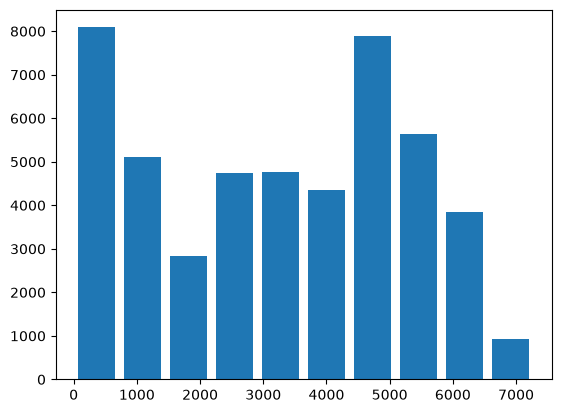

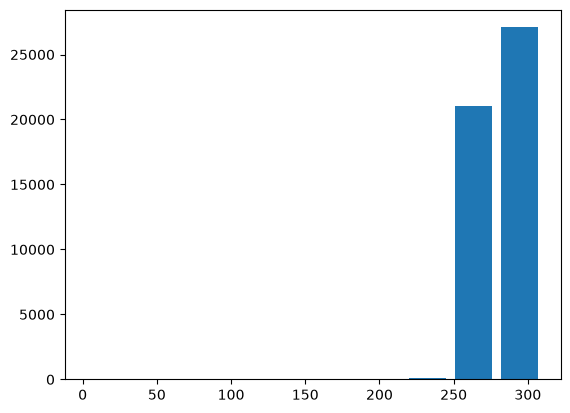

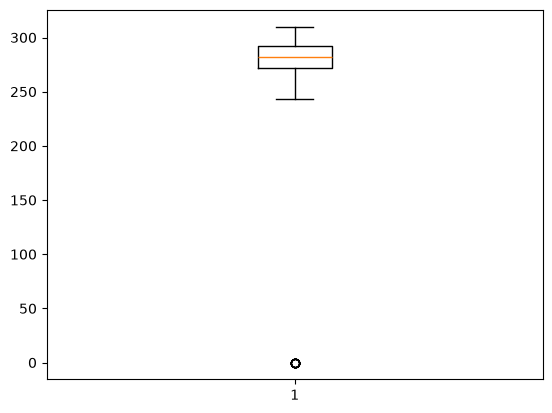

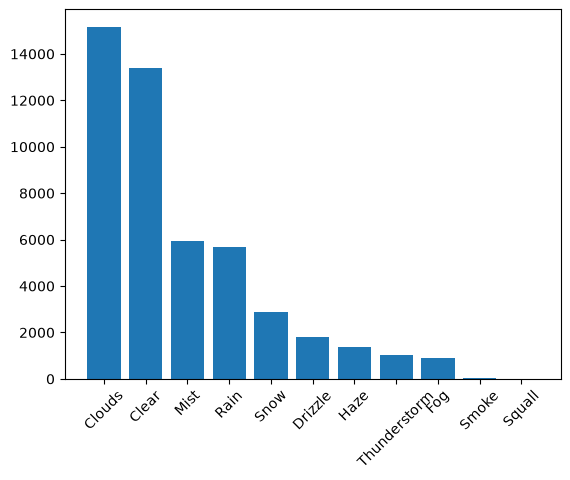

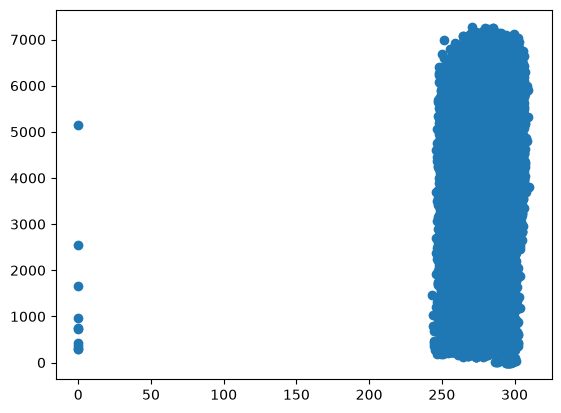

In [36]:
import matplotlib.pyplot as plt                  

plt.hist(df["traffic_volume"], rwidth=0.8)        # Traffic volume
plt.show()

plt.hist(df["temp"], rwidth=0.8)                  # Sebaran frekuensi suhu
plt.show()

plt.boxplot(df["temp"])                          
plt.show()

hitung_cuaca = df["weather_main"].value_counts()  # Menghitung jumlah kemunculan dari tiap jenis cuaca
plt.bar(hitung_cuaca.index, hitung_cuaca.values)  # hitung_cuaca.index: X, hitung_cuaca.values: Y

plt.xticks(rotation=45)                           
plt.show()

plt.scatter(df["temp"], df["traffic_volume"])     # Sumbu X: Suhu, Sumbu Y: Volume kendaraan
plt.show()

## Kesimpulan

**Jawaban dari Pertanyaan Analitis:**
1. **Apakah semua hari kerja memiliki volume kendaraan yang hampir sama?** Berdasarkan data, ternyata volume kendaraan pada setiap hari kerja tidak sama. Jumat ternyata menjadi hari kerja dengan volume kendaraan paling tinggi, sedangkan Senin menjadi yang paling rendah.
2. **Apakah hujan benar-benar membuat jalan lebih sepi?** Hujan tidak langsung membuat jalan menjadi sepi. Saat ada hujan, rata-rata volume kendaraan adalah sekitar 3.292/jam, hampir sama dengan kondisi tidak hujan yang mencapai 3.257/jam. Namun, ketika curah hujan semakin tinggi, rata-rata volume kendaraan turun menjadi sekitar 2.784/jam.

**Temuan Menarik:**
1. Jam 16.00 memang paling ramai, tetapi di waktu pagi dan hari kerja konsisten sama ramainya.
2. Hujan tidak langsung membuat jalan sepi.
3. Jumat adalah hari kerja yang paling ramai, sedangkan Minggu paling sepi.

**Keterbatasan Data:**
Kolom holiday memiliki terlalu banyak data kosong karena format pencatatannya hanya diisi saat hari libur nasional saja. Selain itu, ada anomali sensor suhu (0 Kelvin). Selain itu juga, dataset ini hanya memberikan variabel cuaca, waktu, dan volume kendaraan. Tidak ada informasi seperti alasan perjalanan, kecelakaan, kondisi jalan, atau tujuan pengemudi.

**Ide Pertanyaan Lanjutan:**
1. Pada jam berapa (pagi, siang, atau malam) volume kendaraan mencapai titik puncak (Rush Hour)?
2. Kalau hujan ringan hampir tidak mengubah volume kendaraan, mulai dari curah hujan berapa kendaraan benar-benar mulai berkurang?

## Referensi dan Catatan Penggunaan AI

**Sumber Dataset:**
Dataset "Metro Interstate Traffic Volume" diperoleh dari UCI Machine Learning Repository. (Tautan: https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)

**Tabel Catatan Penggunaan AI:**

| Alat | Dipakai untuk | Yang kami pelajari |
|---|---|---|
| AI (Gemini) | Memahami fungsi kode dasar Pandas (`read_csv`, `shape`, `head`, `info`, `isna`, `duplicated`) dan membandingkannya dengan bahasa C/C++ | Pandas memuat data CSV ke DataFrame secara instan tanpa perlu perulangan manual (`fopen`/`fscanf`) seperti di C/C++. |
| AI (Gemini) | Memahami Kamus Data dan penulisan sintaks tabel Markdown | Kolom `holiday` bernilai `NaN` pada hari biasa, dan simbol garis tegak (`\|`) pada Markdown digunakan untuk membentuk visual tabel HTML. |
| AI (Gemini) | Menginterpretasikan hasil statistik deskriptif (`describe`, `mode`, `var`) | Menemukan anomali sensor pada suhu 0 Kelvin (-273,15°C) serta memahami varians tinggi yang menandakan dinamika volume kendaraan. |
| AI (Gemini) | Memahami analisis variabel kategorik cuaca (`value_counts`) | Menggunakan `normalize=True` untuk menghitung persentase dan `.idxmax()` untuk menentukan modus cuaca utama (`Clouds`). |
| AI (Gemini) | Menyederhanakan kode visualisasi Matplotlib (`hist`, `boxplot`, `bar`, `scatter`) dari level lanjut ke level pemula | Menggunakan fungsi plotting dasar Matplotlib tanpa kustomisasi rumit agar kode terlihat lebih natural untuk tingkat dasar. |
| AI (Gemini) | *Debugging* masalah grafik yang bertumpuk dan teks sumbu X yang berantakan | Pentingnya memanggil `plt.show()` untuk memisahkan kanvas tiap grafik dan `plt.xticks(rotation=45)` agar teks sumbu X tidak bertumpuk. |